## 1 - Dạng 1: Gaussian Blur kết hợp Canny
- Đọc ảnh rose.jpg.
- Chuyển ảnh sang ảnh xám.
- Làm mờ bằng GaussianBlur.
- Phát hiện cạnh bằng Canny.
- Hiển thị và lưu ảnh kết quả.

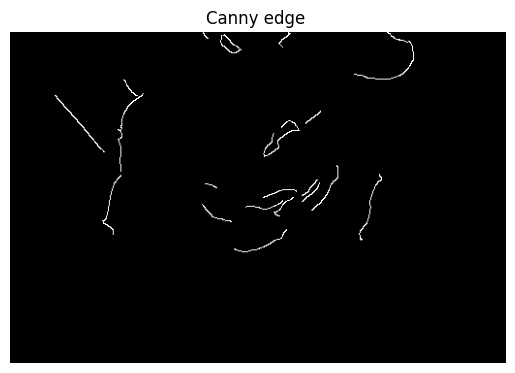

In [2]:
import cv2 
import matplotlib.pyplot as plt 
anh = cv2.imread("roes.jpg")
anh_xam = cv2.cvtColor(anh, cv2.COLOR_BGR2GRAY) # Dòng này thực sự chuyển dữ liệu ảnh màu thành ảnh xám
# nếu đề cho :  GaussianBlur kernel (7, 7), sigma = 1 ,Canny ngưỡng 120 và 250
mo_anh = cv2.GaussianBlur(anh_xam, (7,7), 1 ) # Làm mịn ảnh - giảm nhiễu - tránh canny phát hiện quá nhiều cạnh hoa giả . (7,7) Kích thước kernel 
phat_hien = cv2.Canny(mo_anh, 120, 250) # CANNY phát hiện số cạnh trong ảnh 
plt.imshow(phat_hien, cmap="gray") # Hiển thị các giá trị pixel theo thang màu xám, từ đen đến trắng
plt.axis("off") # Dòng này dùng để ẩn trục tọa độ quanh ảnh.
plt.title("Canny edge ")
plt.show()

## Dạng 2: Phát hiện biên bằng Sobel
- Đọc ảnh → chuyển ảnh xám → resize → Sobel X/Y → kết hợp hai ảnh biên → hiển thị → lưu ảnh.
- Khác với Canny ở dạng 1, Sobel giúp xác định biên theo từng hướng X và Y.
- Đề cho như sau : 
- Cho ảnh mountain.jpg:
    - 1.Đọc ảnh và chuyển sang ảnh xám.
    - 2.Resize ảnh về kích thước 256 × 256.
    - 3.Áp dụng Sobel theo trục X và trục Y.
    - 4.Kết hợp hai kết quả Sobel.
    - 5.Hiển thị và lưu ảnh với tên sobel_mountain.jpg.

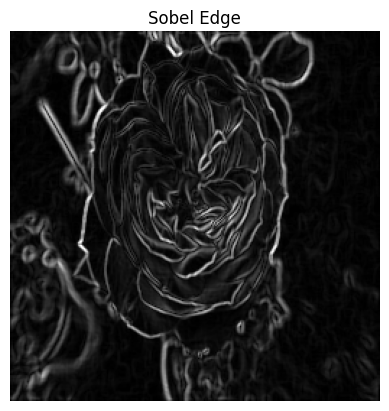

True

In [3]:
# mo_anh = cv2.GaussianBlur(anh_xam, (7,7), 1 ) 
# phat_hien = cv2.Canny(mo_anh, 120, 250)  
# Mk chỉ cần thay 2 đoạn code ở dạng 1 thành như này : 
# Bắt đầu từ ý 2
anh_resize = cv2.resize(anh_xam, (256, 256))
# Ý 3: 
sobel_x = cv2.Sobel(anh_resize, cv2.CV_64F, 1, 0 ) # 1, 0: Sobel theo trục X, thường làm rõ cạnh dọc.
sobel_Y = cv2.Sobel(anh_resize, cv2.CV_64F, 0, 1) # 0, 1: Sobel theo trục Y, thường làm rõ cạnh ngang

sobel_x = cv2.convertScaleAbs(sobel_x) # convertScaleAbs(): chuyển kết quả Sobel về dạng ảnh dễ hiển thị.
sobel_Y = cv2.convertScaleAbs(sobel_Y)
# ý 4 : 
ket_qua = cv2.addWeighted(sobel_x, 0.5, sobel_Y, 0.5, 0 ) # addWeighted(): kết hợp Sobel X và Sobel Y.
# 0.5 thứ nhất Mức đóng góp của sobel_x là 50%
# 0.5  thứ 2 Mức đóng góp của sobel_y là 50%
# 0 cuối cùng - độ sáng cộng thêm vào ảnh kết quả 
# Vẽ lại quay lại dạng 1 
plt.imshow(ket_qua, cmap="gray")
plt.title("Sobel Edge")
plt.axis("off")
plt.show()
# Lưu ảnh 
cv2.imwrite("Dang_2.jpg", ket_qua)


## Dạng 3: Phát hiện đường thẳng bằng Hough Transform
- Hough Transform xem các điểm biên nào nằm gần nhau và tạo thành đường thẳng. Bản chất của nó Canny tìm các điểm cạnh, Hough nối các điểm cạnh thành đường thẳng
- QUY TRÌNH : Đọc ảnh → chuyển ảnh xám → Canny → HoughLinesP → vẽ đường lên ảnh gốc → hiển thị → lưu ảnh
- Cho file ảnh street.jpg(tùy vô đề bài). Thực hiện các yêu cầu sau:
    - 1. Đọc ảnh street.jpg.
    - 2. Chuyển ảnh sang ảnh xám.
    - 3. Áp dụng thuật toán Canny với ngưỡng thấp 60 và ngưỡng cao 180.
    - 4. Phát hiện các đường thẳng bằng Hough Line Transform với threshold=120.
    - 5. Vẽ các đường thẳng phát hiện được lên ảnh gốc.
    - 6. Hiển thị ảnh kết quả.
    - 7. Lưu ảnh kết quả với tên hough_street.jpg.

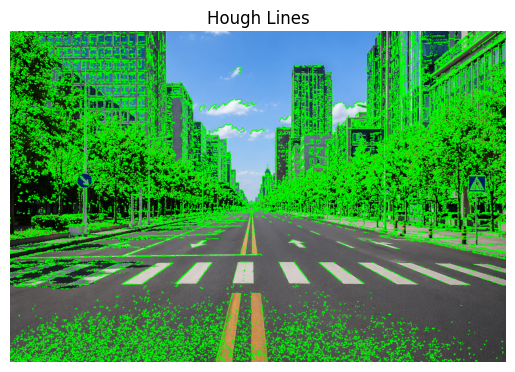

True

In [15]:
# mo_anh = cv2.GaussianBlur(anh_xam, (7,7), 1 ) 
# phat_hien = cv2.Canny(mo_anh, 120, 250)  
# Mk chỉ cần thay 2 đoạn code ở dạng 1 thành như này : 
# Bắt đầu từ ý 3 
import numpy as np 
doc_Anh = cv2.imread("street.png")
anh_xam_dg = cv2.cvtColor(doc_Anh, cv2.COLOR_BGR2GRAY)
bien = cv2.Canny(anh_xam_dg, 60, 180)
# Ý 4:
duong_thang =cv2.HoughLinesP(bien, 1, np.pi / 180, threshold= 120 )
# 1 là độ phân giải , np.pi / 180 là độ phân giải góc bằng 1 độ ,
# Ý 5: 
if duong_thang is not None: 
    for duong in duong_thang:
        x1, y1, x2, y2 = duong[0]
        cv2.line(doc_Anh, (x1, y1), (x2, y2), (0, 250, 0), 2)
anh_rgb = cv2.cvtColor(doc_Anh, cv2.COLOR_BGR2RGB) ## e chú ý cv2.COLOR_BGR2RGB với đoạn code dòng thứ 7 
plt.imshow(anh_rgb)
plt.axis("off")
plt.title("Hough Lines")
plt.show() 
cv2.imwrite("Dang_3.jpg", doc_Anh)

| Thành phần    | Công dụng            |
| ------------- | -------------------- |
| `anh`         | ảnh cần vẽ           |
| `(x1, y1)`    | điểm đầu             |
| `(x2, y2)`    | điểm cuối            |
| `(0, 255, 0)` | màu xanh lá theo BGR |
| `2`           | độ dày đường         |
 độ dày đường mình có thể bỏ nếu đề hỏi thì mk thêm vô 


## Dạng 4: Resize ảnh và làm mờ bằng Median Blur
- Quy trình : Đọc ảnh → chuyển ảnh xám → resize → Median Blur → hiển thị → lưu ảnh
- Đề bài có thể ra như sau:
    1. Cho file ảnh tulip.jpg.
    2. Đọc ảnh và chuyển sang ảnh xám.
    3. Resize ảnh về kích thước 80 × 80.
    4. Áp dụng bộ lọc Median Blur với kernel bằng 5.
    5. Hiển thị ảnh kết quả.
    6. Lưu ảnh với tên median_tulip.jpg.

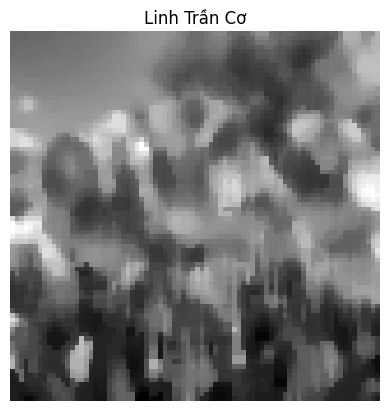

In [9]:
import cv2 
import matplotlib.pyplot as plt 
doc_anh4 = cv2.imread("tulip.png")
anh_xam4= cv2.cvtColor(doc_anh4, cv2.COLOR_BGR2GRAY)
resize4 = cv2.resize(anh_xam4, (80, 80))
loc4 = cv2.medianBlur(resize4, 5)
plt.imshow(loc4, cmap="gray")
plt.title("Linh Trần Cơ")
plt.axis("off")
plt.show()

## Dạng 5: Canny kết hợp Hough Transform trên ảnh đường cao tốc
- Dạng 5 gần giống dạng 3, nhưng sử dụng ảnh highway.jpg và ngưỡng Canny khác.
- Đề bài:
    - Cho file ảnh highway.jpg:
        1. Đọc ảnh và chuyển sang ảnh xám.
        2. Áp dụng phát hiện cạnh Canny với ngưỡng 90 và 220.
        3. Phát hiện đường thẳng bằng Hough Transform.
        4. Vẽ các đường thẳng phát hiện được lên ảnh gốc.
        5. Hiển thị và lưu ảnh với tên hough_lines_highway.jpg

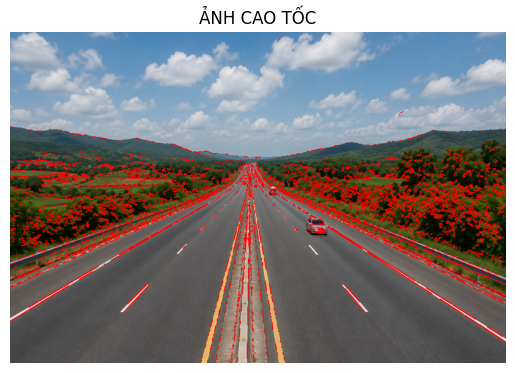

In [26]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np 
doc_anh5= cv2.imread("cao_toc.png")
anh_xam5 = cv2.cvtColor(doc_anh5, cv2.COLOR_BGR2GRAY)
bien5 = cv2.Canny(anh_xam5, 90, 220)
duong_thang5 = cv2.HoughLinesP(bien5, 1,  np.pi / 180 , threshold= 100)
if duong_thang5 is not None: 
    for duong5 in duong_thang5 : 
        X1, Y1, X2, Y2 = duong5[0]
        cv2.line(doc_anh5, (X1, Y1), (X2, Y2), (0, 0,255), 2)
anh_rgb5 = cv2.cvtColor(doc_anh5, cv2.COLOR_BGR2RGB)
plt.imshow(anh_rgb5)
plt.axis("off")
plt.title("ẢNH CAO TỐC")
plt.show()